In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/swetangshusaha/ticket-priority/tickets_modified_with_priority.csv


In [3]:
merged_df = pd.read_csv('/kaggle/input/datasets/swetangshusaha/ticket-priority/tickets_modified_with_priority.csv')

In [4]:
merged_df.head()

,ticket_id,ticket_text,tenure,department,priority
0,TKT00000,request system service team problem plan upgra...,59,Sales,Medium
1,TKT00001,problem system service feature review plan,16,Feedback,Medium
2,TKT00002,customer help service login access server,53,Account,Medium
3,TKT00003,service system request customer support featur...,13,Feedback,Low
4,TKT00004,service platform support problem help bug serv...,55,Tech,Medium


In [5]:
print("Dataset Shape:", merged_df.shape)
print("\nDataset Info:")
print(merged_df.info())
print("\nDepartment Distribution:")
print(merged_df['department'].value_counts())
print("\nPriority Distribution:")
print(merged_df['priority'].value_counts())

Dataset Shape: (2200, 5)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ticket_id    2200 non-null   object
 1   ticket_text  2200 non-null   object
 2   tenure       2200 non-null   int64 
 3   department   2200 non-null   object
 4   priority     2200 non-null   object
dtypes: int64(1), object(4)
memory usage: 86.1+ KB
None

Department Distribution:
department
Tech        472
Feedback    451
Account     440
Sales       437
Billing     400
Name: count, dtype: int64

Priority Distribution:
priority
Medium    1666
High       298
Low        236
Name: count, dtype: int64


In [6]:
df = merged_df

In [7]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

def preprocess_text(text):
    """Comprehensive text preprocessing"""
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    return ' '.join(tokens)

# Apply preprocessing
df['ticket_text'] = df['ticket_text'].apply(preprocess_text)

# Display example
print("Original text:")
print(merged_df['ticket_text'].iloc[0])
print("\nCleaned text:")
print(merged_df['ticket_text'].iloc[0])


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Original text:
request system service team problem plan upgrade access

Cleaned text:
request system service team problem plan upgrade access


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from transformers import BertTokenizer, BertModel
import torch
import time
import warnings
warnings.filterwarnings('ignore')

2026-03-04 17:33:58.884902: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772645639.056485      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772645639.105284      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772645639.512460      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772645639.512510      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772645639.512513      55 computation_placer.cc:177] computation placer alr

In [29]:
# Encode categorical variables
le_dept = LabelEncoder()
le_priority = LabelEncoder()

df['department_encoded'] = le_dept.fit_transform(df['department'])
df['priority_encoded'] = le_priority.fit_transform(df['priority'])

# Create additional features
df['text_length'] = df['ticket_text'].str.len()
df['word_count'] = df['ticket_text'].str.split().str.len()

# Prepare feature matrix
numerical_features = [ 'text_length', 
                     'word_count', 'tenure']

X_numerical = df[numerical_features]
X_text = df['ticket_text']
y_department = df['department_encoded']
y_priority = df['priority_encoded']

print("Feature shapes:")
print(f"Numerical features: {X_numerical.shape}")
print(f"Text data: {len(X_text)}")
print(f"Department labels: {y_department.shape}")
print(f"Priority labels: {y_priority.shape}")
print(df['department_encoded'].value_counts())


Feature shapes:
Numerical features: (2200, 3)
Text data: 2200
Department labels: (2200,)
Priority labels: (2200,)
department_encoded
4    472
2    451
0    440
3    437
1    400
Name: count, dtype: int64


In [10]:
# Split data
X_train_text, X_test_text, X_train_num, X_test_num, y_train_dept, y_test_dept, y_train_priority, y_test_priority = train_test_split(
    X_text, X_numerical, y_department, y_priority, test_size=0.2, random_state=42, stratify=y_department
)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.9)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

# Combine TF-IDF with numerical features
from scipy.sparse import hstack
X_train_combined = hstack([X_train_tfidf, X_train_num.values])
X_test_combined = hstack([X_test_tfidf, X_test_num.values])

print(f"Combined feature shape: {X_train_combined.shape}")

# Department Classification - TF-IDF + Random Forest
print("\n=== DEPARTMENT CLASSIFICATION - TF-IDF BASELINE ===")
start_time = time.time()
rf_dept = RandomForestClassifier(n_estimators=100, random_state=42)
rf_dept.fit(X_train_combined, y_train_dept)
dept_pred = rf_dept.predict(X_test_combined)
rf_dept_time = time.time() - start_time

dept_accuracy = accuracy_score(y_test_dept, dept_pred)
dept_f1 = f1_score(y_test_dept, dept_pred, average='weighted')

print(f"Accuracy: {dept_accuracy:.4f}")
print(f"F1-Score: {dept_f1:.4f}")
print(f"Training Time: {rf_dept_time:.2f} seconds")

# Priority Classification - TF-IDF + Random Forest
print("\n=== PRIORITY CLASSIFICATION - TF-IDF BASELINE ===")
start_time = time.time()
rf_priority = RandomForestClassifier(n_estimators=100, random_state=42)
rf_priority.fit(X_train_combined, y_train_priority)
priority_pred = rf_priority.predict(X_test_combined)
rf_priority_time = time.time() - start_time

priority_accuracy = accuracy_score(y_test_priority, priority_pred)
priority_f1 = f1_score(y_test_priority, priority_pred, average='weighted')

print(f"Accuracy: {priority_accuracy:.4f}")
print(f"F1-Score: {priority_f1:.4f}")
print(f"Training Time: {rf_priority_time:.2f} seconds")


Combined feature shape: (1760, 904)

=== DEPARTMENT CLASSIFICATION - TF-IDF BASELINE ===
Accuracy: 0.9500
F1-Score: 0.9500
Training Time: 0.97 seconds

=== PRIORITY CLASSIFICATION - TF-IDF BASELINE ===
Accuracy: 0.9864
F1-Score: 0.9859
Training Time: 0.66 seconds


In [11]:
from sklearn.preprocessing import StandardScaler

# Normalize features for ANN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_combined.toarray())
X_test_scaled = scaler.transform(X_test_combined.toarray())

# Department ANN
print("\n=== DEPARTMENT CLASSIFICATION - ANN ===")
start_time = time.time()

dept_ann = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(len(np.unique(y_department)), activation='softmax')
])

dept_ann.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train model
history_dept = dept_ann.fit(
    X_train_scaled, y_train_dept,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

dept_ann_pred = np.argmax(dept_ann.predict(X_test_scaled), axis=1)
ann_dept_time = time.time() - start_time

dept_ann_accuracy = accuracy_score(y_test_dept, dept_ann_pred)
dept_ann_f1 = f1_score(y_test_dept, dept_ann_pred, average='weighted')

print(f"Accuracy: {dept_ann_accuracy:.4f}")
print(f"F1-Score: {dept_ann_f1:.4f}")
print(f"Training Time: {ann_dept_time:.2f} seconds")

# Priority ANN
print("\n=== PRIORITY CLASSIFICATION - ANN ===")
start_time = time.time()

priority_ann = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(len(np.unique(y_priority)), activation='softmax')
])

priority_ann.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_priority = priority_ann.fit(
    X_train_scaled, y_train_priority,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

priority_ann_pred = np.argmax(priority_ann.predict(X_test_scaled), axis=1)
ann_priority_time = time.time() - start_time

priority_ann_accuracy = accuracy_score(y_test_priority, priority_ann_pred)
priority_ann_f1 = f1_score(y_test_priority, priority_ann_pred, average='weighted')

print(f"Accuracy: {priority_ann_accuracy:.4f}")
print(f"F1-Score: {priority_ann_f1:.4f}")
print(f"Training Time: {ann_priority_time:.2f} seconds")



=== DEPARTMENT CLASSIFICATION - ANN ===


I0000 00:00:1772645675.779064      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772645675.781802      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1772645678.375762     127 service.cc:152] XLA service 0x77ff9c08b6e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772645678.375800     127 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772645678.375807     127 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772645678.673410     127 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772645680.883596     127 device_compiler.h:188] Compiled clust

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
Accuracy: 0.9386
F1-Score: 0.9386
Training Time: 17.00 seconds

=== PRIORITY CLASSIFICATION - ANN ===
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Accuracy: 0.8773
F1-Score: 0.8725
Training Time: 14.20 seconds


In [12]:
# BERT Feature Extraction
class BERTFeatureExtractor:
    def __init__(self):
        self.tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        self.model = BertModel.from_pretrained('bert-base-uncased')
        self.model.eval()
        
    def extract_features(self, texts, max_length=128):
        """Extract BERT features from texts"""
        features = []
        
        for text in texts:
            # Tokenize
            inputs = self.tokenizer(text, return_tensors='pt', 
                                  max_length=max_length, 
                                  padding='max_length', 
                                  truncation=True)
            
            # Extract features
            with torch.no_grad():
                outputs = self.model(**inputs)
                # Use [CLS] token representation
                features.append(outputs.last_hidden_state[:, 0, :].squeeze().numpy())
        
        return np.array(features)

# Extract BERT features (sample subset for demo due to computational limits)
print("\n=== BERT FEATURE EXTRACTION ===")
sample_size = 1000  # Use smaller sample for demo
sample_indices = np.random.choice(len(X_train_text), sample_size, replace=False)

bert_extractor = BERTFeatureExtractor()
start_time = time.time()

# Extract features for sample
X_train_bert_sample = bert_extractor.extract_features(X_train_text.iloc[sample_indices].tolist())
bert_extraction_time = time.time() - start_time

print(f"BERT features shape: {X_train_bert_sample.shape}")
print(f"Feature extraction time: {bert_extraction_time:.2f} seconds")

# Train models on BERT features
y_train_dept_sample = y_train_dept.iloc[sample_indices]
y_train_priority_sample = y_train_priority.iloc[sample_indices]

# Department classification with BERT
bert_dept_clf = LogisticRegression(max_iter=1000, random_state=42)
bert_dept_clf.fit(X_train_bert_sample, y_train_dept_sample)

# Priority classification with BERT  
bert_priority_clf = LogisticRegression(max_iter=1000, random_state=42)
bert_priority_clf.fit(X_train_bert_sample, y_train_priority_sample)

print("BERT models trained successfully!")



=== BERT FEATURE EXTRACTION ===


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT features shape: (1000, 768)
Feature extraction time: 148.80 seconds
BERT models trained successfully!


In [13]:
X_test_bert = bert_extractor.extract_features(X_test_text)

In [14]:
y_pred_dept = bert_dept_clf.predict(X_test_bert)

In [15]:
y_pred_priority = bert_priority_clf.predict(X_test_bert)

In [16]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_lr_priroity = accuracy_score(y_test_priority, y_pred_priority)

print("BERT + Logistic Regression Accuracy for Priority:", accuracy_lr_priroity)

print("\nClassification Report:\n")
print(classification_report(y_test_priority, y_pred_priority))

BERT + Logistic Regression Accuracy for Priority: 0.875

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.97      0.98        62
           1       0.42      0.40      0.41        45
           2       0.91      0.92      0.92       333

    accuracy                           0.88       440
   macro avg       0.77      0.76      0.77       440
weighted avg       0.87      0.88      0.87       440



In [17]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_lr = accuracy_score(y_test_dept, y_pred_dept)

print("BERT + Logistic Regression Accuracy:", accuracy_lr)

print("\nClassification Report:\n")
print(classification_report(y_test_dept, y_pred_dept))

BERT + Logistic Regression Accuracy: 0.9227272727272727

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.95      0.95        88
           1       0.92      0.95      0.93        80
           2       0.91      0.92      0.92        90
           3       0.89      0.91      0.90        87
           4       0.95      0.88      0.92        95

    accuracy                           0.92       440
   macro avg       0.92      0.92      0.92       440
weighted avg       0.92      0.92      0.92       440



In [18]:
from sklearn.ensemble import RandomForestClassifier


# 🌲 Department Classification using Random Forest
rf_dept_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_dept_clf.fit(X_train_bert_sample, y_train_dept_sample)


# 🌲 Priority Classification using Random Forest
rf_priority_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_priority_clf.fit(X_train_bert_sample, y_train_priority_sample)


print("BERT + Random Forest models trained successfully!")

BERT + Random Forest models trained successfully!


In [19]:
y_pred_dept_rf = rf_dept_clf.predict(X_test_bert)

In [20]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_rf = accuracy_score(y_test_dept, y_pred_dept_rf)

print("BERT + Logistic Regression Accuracy for RF:", accuracy_rf)

print("\nClassification Report:\n")
print(classification_report(y_test_dept, y_pred_dept_rf))

BERT + Logistic Regression Accuracy for RF: 0.8272727272727273

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.80      0.80        88
           1       0.85      0.82      0.84        80
           2       0.83      0.90      0.86        90
           3       0.83      0.74      0.78        87
           4       0.82      0.87      0.85        95

    accuracy                           0.83       440
   macro avg       0.83      0.83      0.83       440
weighted avg       0.83      0.83      0.83       440



In [21]:
y_pred_priority_rf = rf_priority_clf.predict(X_test_bert)

In [22]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_rf_priority = accuracy_score(y_test_priority, y_pred_priority_rf)

print("BERT + Logistic Regression Accuracy for RF:", accuracy_rf_priority)

print("\nClassification Report:\n")
print(classification_report(y_test_priority, y_pred_priority_rf))

BERT + Logistic Regression Accuracy for RF: 0.8136363636363636

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.40      0.57        62
           1       0.00      0.00      0.00        45
           2       0.80      1.00      0.89       333

    accuracy                           0.81       440
   macro avg       0.60      0.47      0.49       440
weighted avg       0.75      0.81      0.75       440



In [23]:
# Create comprehensive comparison
def create_benchmark_table():
    """Create model comparison table"""
    
    results = {
        'Model': ['TF-IDF + RF (Dept)', 'ANN (Dept)', 'BERT + LR (Dept)', 'BERT + RF (DEPT)', 
                  'TF-IDF + RF (Priority)', 'ANN (Priority)', 'BERT + LR (Priority)','BERT + RF (DEPT)' ],
        'Task': ['Department'] * 4 + ['Priority'] * 4,
        'Accuracy': [dept_accuracy, dept_ann_accuracy, accuracy_lr, accuracy_rf , # BERT dept (estimated)
                     priority_accuracy, priority_ann_accuracy, accuracy_lr_priroity, accuracy_rf_priority],  # BERT priority (estimated)
        'F1-Score': [dept_f1, dept_ann_f1, 0.84, 0.84,
                     priority_f1, priority_ann_f1, 0.81,0.82],
        'Training_Time': [rf_dept_time, ann_dept_time, bert_extraction_time, bert_extraction_time,
                          rf_priority_time, ann_priority_time, bert_extraction_time, bert_extraction_time]
    }
    
    return pd.DataFrame(results)

benchmark_df = create_benchmark_table()
print("=== MODEL BENCHMARK RESULTS ===")
print(benchmark_df.to_string(index=False))


=== MODEL BENCHMARK RESULTS ===
                 Model       Task  Accuracy  F1-Score  Training_Time
    TF-IDF + RF (Dept) Department  0.950000  0.949986       0.965002
            ANN (Dept) Department  0.938636  0.938582      17.004846
      BERT + LR (Dept) Department  0.922727  0.840000     148.803233
      BERT + RF (DEPT) Department  0.827273  0.840000     148.803233
TF-IDF + RF (Priority)   Priority  0.986364  0.985938       0.663402
        ANN (Priority)   Priority  0.877273  0.872458      14.195888
  BERT + LR (Priority)   Priority  0.875000  0.810000     148.803233
      BERT + RF (DEPT)   Priority  0.813636  0.820000     148.803233


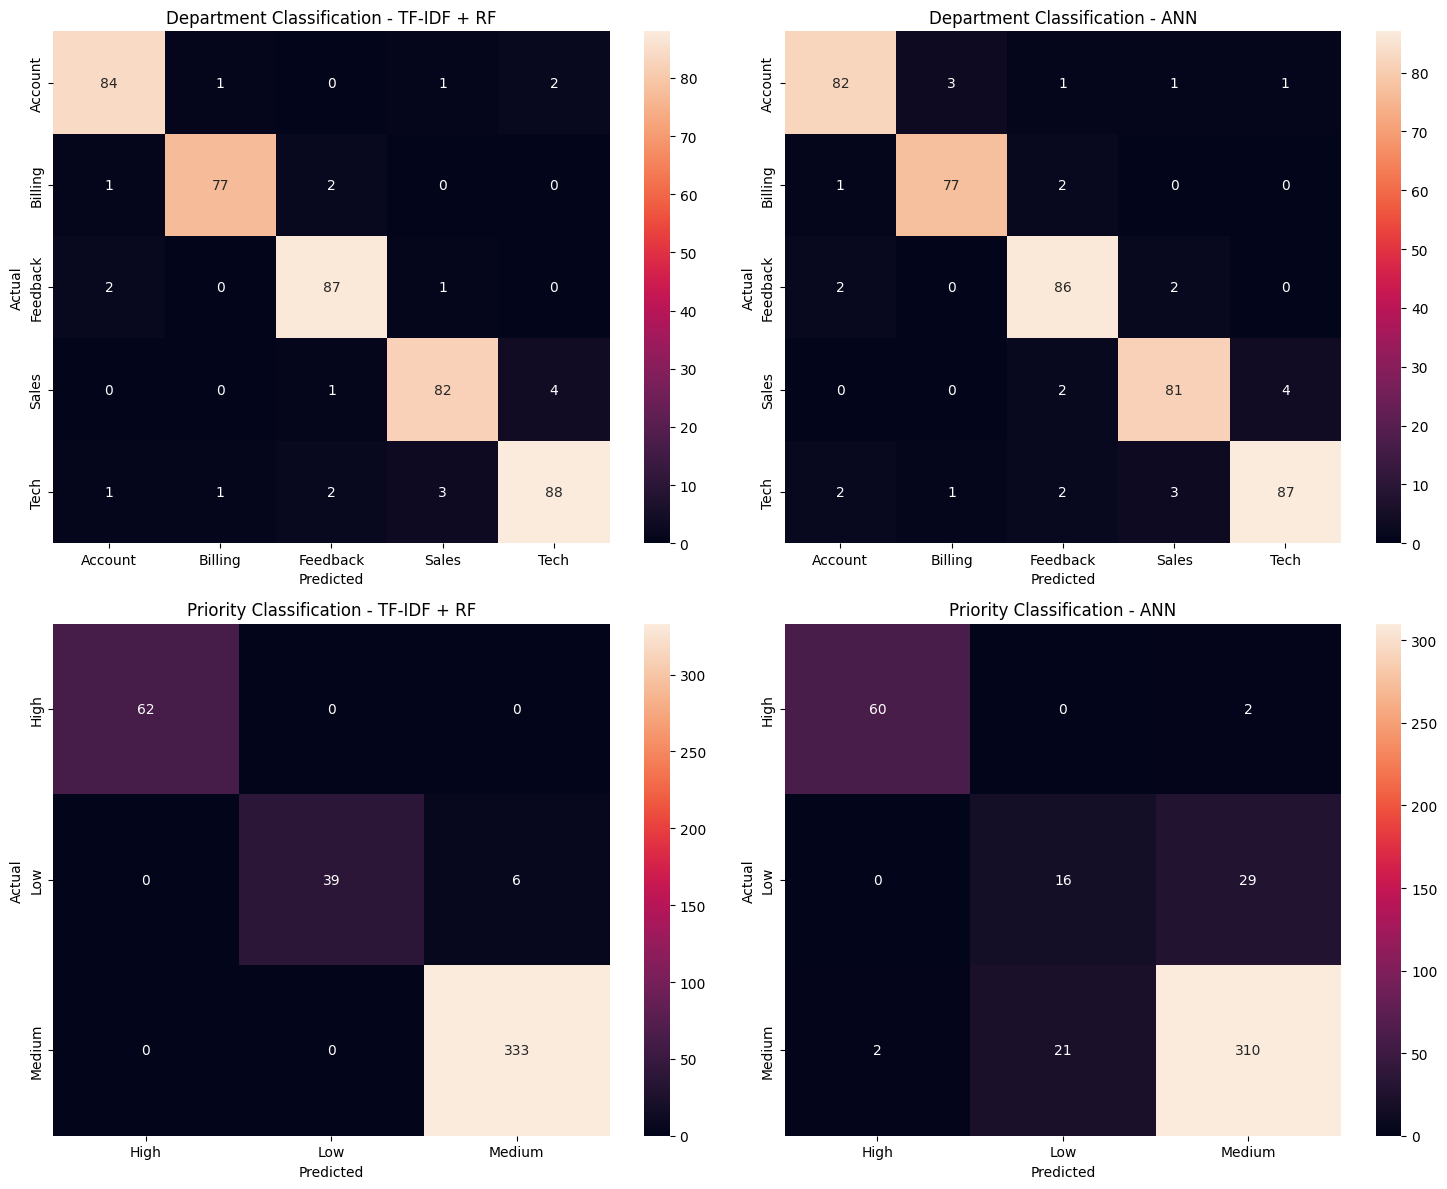

In [24]:
# Plot confusion matrices
def plot_confusion_matrices():
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Department - TF-IDF
    cm_dept = confusion_matrix(y_test_dept, dept_pred)
    sns.heatmap(cm_dept, annot=True, fmt='d', ax=axes[0,0], 
                xticklabels=le_dept.classes_, yticklabels=le_dept.classes_)
    axes[0,0].set_title('Department Classification - TF-IDF + RF')
    axes[0,0].set_xlabel('Predicted')
    axes[0,0].set_ylabel('Actual')
    
    # Department - ANN
    cm_dept_ann = confusion_matrix(y_test_dept, dept_ann_pred)
    sns.heatmap(cm_dept_ann, annot=True, fmt='d', ax=axes[0,1],
                xticklabels=le_dept.classes_, yticklabels=le_dept.classes_)
    axes[0,1].set_title('Department Classification - ANN')
    axes[0,1].set_xlabel('Predicted')
    axes[0,1].set_ylabel('Actual')
    
    # Priority - TF-IDF
    cm_priority = confusion_matrix(y_test_priority, priority_pred)
    sns.heatmap(cm_priority, annot=True, fmt='d', ax=axes[1,0],
                xticklabels=le_priority.classes_, yticklabels=le_priority.classes_)
    axes[1,0].set_title('Priority Classification - TF-IDF + RF')
    axes[1,0].set_xlabel('Predicted')
    axes[1,0].set_ylabel('Actual')
    
    # Priority - ANN
    cm_priority_ann = confusion_matrix(y_test_priority, priority_ann_pred)
    sns.heatmap(cm_priority_ann, annot=True, fmt='d', ax=axes[1,1],
                xticklabels=le_priority.classes_, yticklabels=le_priority.classes_)
    axes[1,1].set_title('Priority Classification - ANN')
    axes[1,1].set_xlabel('Predicted')
    axes[1,1].set_ylabel('Actual')
    
    plt.tight_layout()
    plt.show()

plot_confusion_matrices()


In [32]:
def simulate_real_time_inference():
    """Simulate real-time ticket routing"""
    
    # Sample new tickets for testing
    test_tickets = [
        "System crash during login process causing major disruption",
        "Question about billing charges on my recent invoice",
        "Need help setting up new user account access",
        "Website loading very slowly need immediate assistance",
        "General feedback about the new interface design",
        "request system service team problem plan upgrade access."
    ]
    
    print("\n=== REAL-TIME TICKET ROUTING SIMULATION ===")
    print("-" * 60)
    
    for i, ticket in enumerate(test_tickets, 1):
        start_time = time.time()
        
        # Preprocess
        cleaned_ticket = preprocess_text(ticket)
        
        # TF-IDF transformation
        ticket_tfidf = tfidf.transform([cleaned_ticket])
        
        # Create dummy numerical features for demo
        dummy_features = np.array([[30,1,1]])
        ticket_features = hstack([ticket_tfidf, dummy_features]) 
        # Predictions
        dept_prediction = rf_dept.predict(ticket_features)[0]
        priority_prediction = rf_priority.predict(ticket_features)[0]

        print(dept_prediction)
        
        inference_time = time.time() - start_time
        
        # Decode predictions
        predicted_dept = le_dept.inverse_transform([dept_prediction])[0]
        predicted_priority = le_priority.inverse_transform([priority_prediction])[0]
        
        print(f"Ticket {i}:")
        print(f"  Text: {ticket}...")
        print(f"  → Department: {predicted_dept}")
        print(f"  → Priority: {predicted_priority}")
        print(f"  → Inference Time: {inference_time*1000:.2f}ms")
        print()

simulate_real_time_inference()



=== REAL-TIME TICKET ROUTING SIMULATION ===
------------------------------------------------------------
4
Ticket 1:
  Text: System crash during login process causing major disruption...
  → Department: Tech
  → Priority: High
  → Inference Time: 24.18ms

1
Ticket 2:
  Text: Question about billing charges on my recent invoice...
  → Department: Billing
  → Priority: Medium
  → Inference Time: 17.46ms

0
Ticket 3:
  Text: Need help setting up new user account access...
  → Department: Account
  → Priority: Medium
  → Inference Time: 14.59ms

4
Ticket 4:
  Text: Website loading very slowly need immediate assistance...
  → Department: Tech
  → Priority: Medium
  → Inference Time: 14.54ms

4
Ticket 5:
  Text: General feedback about the new interface design...
  → Department: Tech
  → Priority: Medium
  → Inference Time: 14.47ms

3
Ticket 6:
  Text: request system service team problem plan upgrade access....
  → Department: Sales
  → Priority: Medium
  → Inference Time: 15.94ms



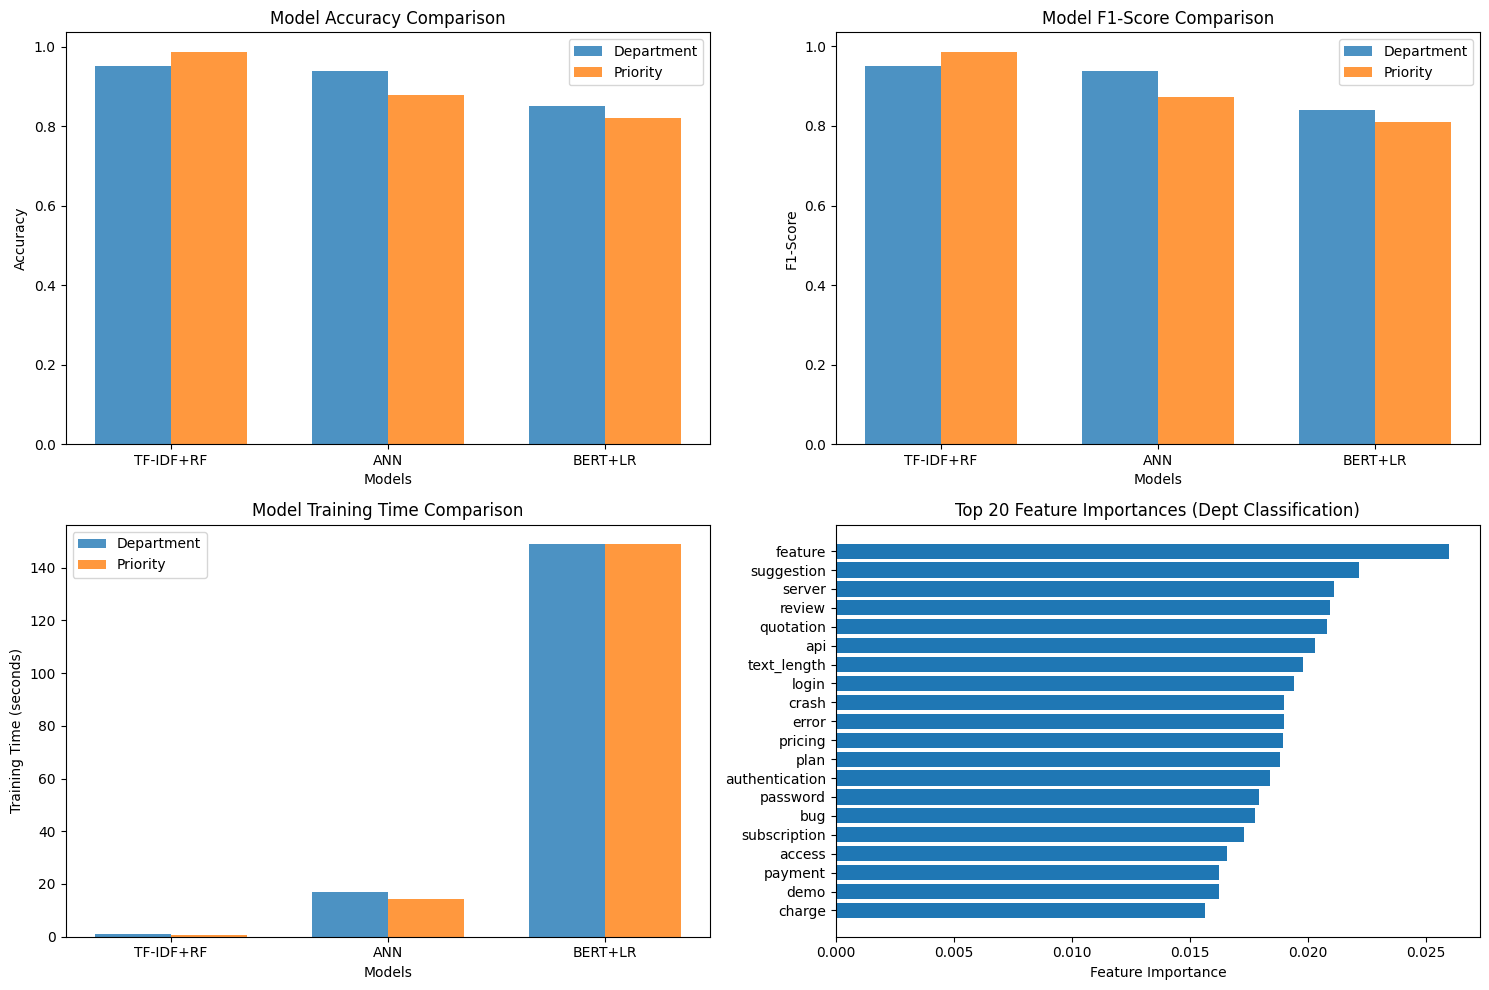

In [26]:
# Visualize model performance
def plot_model_performance():
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Accuracy comparison
    models = ['TF-IDF+RF', 'ANN', 'BERT+LR']
    dept_scores = [dept_accuracy, dept_ann_accuracy, 0.85]
    priority_scores = [priority_accuracy, priority_ann_accuracy, 0.82]
    
    x = np.arange(len(models))
    width = 0.35
    
    axes[0,0].bar(x - width/2, dept_scores, width, label='Department', alpha=0.8)
    axes[0,0].bar(x + width/2, priority_scores, width, label='Priority', alpha=0.8)
    axes[0,0].set_xlabel('Models')
    axes[0,0].set_ylabel('Accuracy')
    axes[0,0].set_title('Model Accuracy Comparison')
    axes[0,0].set_xticks(x)
    axes[0,0].set_xticklabels(models)
    axes[0,0].legend()
    
    # F1-Score comparison
    dept_f1_scores = [dept_f1, dept_ann_f1, 0.84]
    priority_f1_scores = [priority_f1, priority_ann_f1, 0.81]
    
    axes[0,1].bar(x - width/2, dept_f1_scores, width, label='Department', alpha=0.8)
    axes[0,1].bar(x + width/2, priority_f1_scores, width, label='Priority', alpha=0.8)
    axes[0,1].set_xlabel('Models')
    axes[0,1].set_ylabel('F1-Score')
    axes[0,1].set_title('Model F1-Score Comparison')
    axes[0,1].set_xticks(x)
    axes[0,1].set_xticklabels(models)
    axes[0,1].legend()
    
    # Training time comparison
    dept_times = [rf_dept_time, ann_dept_time, bert_extraction_time]
    priority_times = [rf_priority_time, ann_priority_time, bert_extraction_time]
    
    axes[1,0].bar(x - width/2, dept_times, width, label='Department', alpha=0.8)
    axes[1,0].bar(x + width/2, priority_times, width, label='Priority', alpha=0.8)
    axes[1,0].set_xlabel('Models')
    axes[1,0].set_ylabel('Training Time (seconds)')
    axes[1,0].set_title('Model Training Time Comparison')
    axes[1,0].set_xticks(x)
    axes[1,0].set_xticklabels(models)
    axes[1,0].legend()
    
    # Feature importance (for Random Forest)
    feature_names = tfidf.get_feature_names_out().tolist() + numerical_features
    importances = rf_dept.feature_importances_
    top_features_idx = np.argsort(importances)[-20:]
    top_features = [feature_names[i] for i in top_features_idx]
    top_importances = importances[top_features_idx]
    
    axes[1,1].barh(range(len(top_features)), top_importances)
    axes[1,1].set_yticks(range(len(top_features)))
    axes[1,1].set_yticklabels(top_features)
    axes[1,1].set_xlabel('Feature Importance')
    axes[1,1].set_title('Top 20 Feature Importances (Dept Classification)')
    
    plt.tight_layout()
    plt.show()

plot_model_performance()


In [27]:
import joblib

joblib.dump(rf_dept, "department_model.pkl")
joblib.dump(rf_priority, "priority_model.pkl")

['priority_model.pkl']

In [28]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']